Initial density matrix rho(0):
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[1. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

Density matrix after π/2 x-rotation on spin I (rho_rotated):
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5+0.j  0. +0.j  0. +0.5j 0. +0.j ]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. -0.5j 0. +0.j  0.5+0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j ]]

Density matrix rho(t) at t = 0.005 seconds:
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0.5+0.j  0. +0.j  0. -0.5j 0. +0.j ]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j ]
 [0. +0.5j 0. +0.j  0.5+0.j  0. +0.j ]
 [0. +0.j  0. +0.j  0. +0.j  0. +0.j ]]

Interaction Hamiltonian H_IS:
Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[ 314.15926536    0.            0.            0

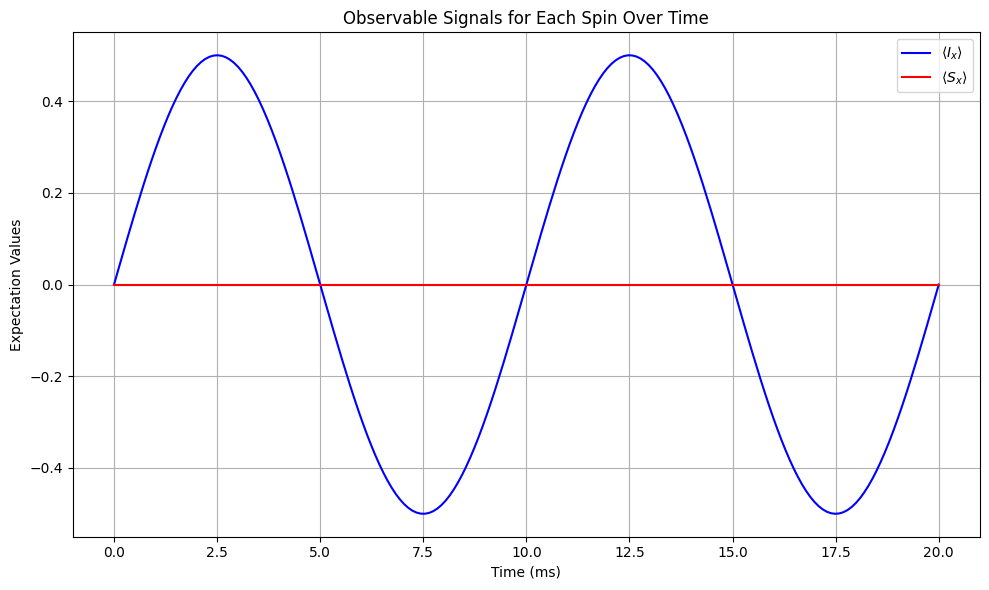

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import tensor, qeye, sigmax, sigmaz, Qobj, mesolve

sx = sigmax()
sz = sigmaz()
E = qeye(2)
Ix = 0.5 * tensor(sx, E)
Iz = 0.5 * tensor(sz, E)
Sx = 0.5 * tensor(E, sx)
Sz = 0.5 * tensor(E, sz)

# a
rho0 = 0.25 * tensor(E, E) + 0.5 * Iz + 0.5 * Sz + Iz * Sz

print("Initial density matrix rho(0):")
print(rho0)

theta = np.pi / 2
U_I = (-1j * theta * sx / 2).expm()
U = tensor(U_I, E)
rho_rotated = U * rho0 * U.dag()

print("\nDensity matrix after π/2 x-rotation on spin I (rho_rotated):")
print(rho_rotated)


# b
J = 200
H_IS = 2 * np.pi * J * Iz * Sz
t = 0.005
U_t = (-1j * H_IS * t).expm()
rho_t = U_t * rho_rotated * U_t.dag()
print(f"\nDensity matrix rho(t) at t = {t} seconds:")
print(rho_t)
print("\nInteraction Hamiltonian H_IS:")
print(H_IS)

# c
O_I = Ix
O_S = Sx

observables = [O_I, O_S]

t_max = 0.02
num_steps = 200
tlist = np.linspace(0, t_max, num_steps)

result = mesolve(H_IS, rho_rotated, tlist, [], observables)

expect_OI = result.expect[0]
expect_OS = result.expect[1]

plt.figure(figsize=(10, 6))
plt.plot(tlist * 1000, expect_OI, label=r'$\langle I_x \rangle$', color='blue')
plt.plot(tlist * 1000, expect_OS, label=r'$\langle S_x \rangle$', color='red')
plt.title('Observable Signals')
plt.xlabel('Time')
plt.ylabel('Expectation Values')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
